In [6]:
import os 
import numpy as np
import pandas as pd
import json
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

from src.setting import ExcludSubj, GetInfo, get_data_grp
from src.config import OUT_PATH, COL_REG
from src.decomposition import CompoThr


In [2]:
epoch_path = OUT_PATH + '/Data_longWOBS'
subj_included = [file.replace('_epochs.p', '') for file in os.listdir(epoch_path) if file[-len('epochs.p'):] == 'epochs.p']
subj_included = ExcludSubj(subj_included=subj_included, data_path=epoch_path)

coord, areas, elect_list, subj_list, region = GetInfo(subj_included, data_path=epoch_path)

print('Number of subject is ', len(subj_included))


Number of subject is  30


In [3]:
df = pd.DataFrame({'area' : region, 'subject': subj_list})

/tmp/ipykernel_13662/2093600642.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub["area"] = pd.Categorical(
/tmp/ipykernel_13662/2093600642.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub["area"] = pd.Categorical(
/tmp/ipykernel_13662/2093600642.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

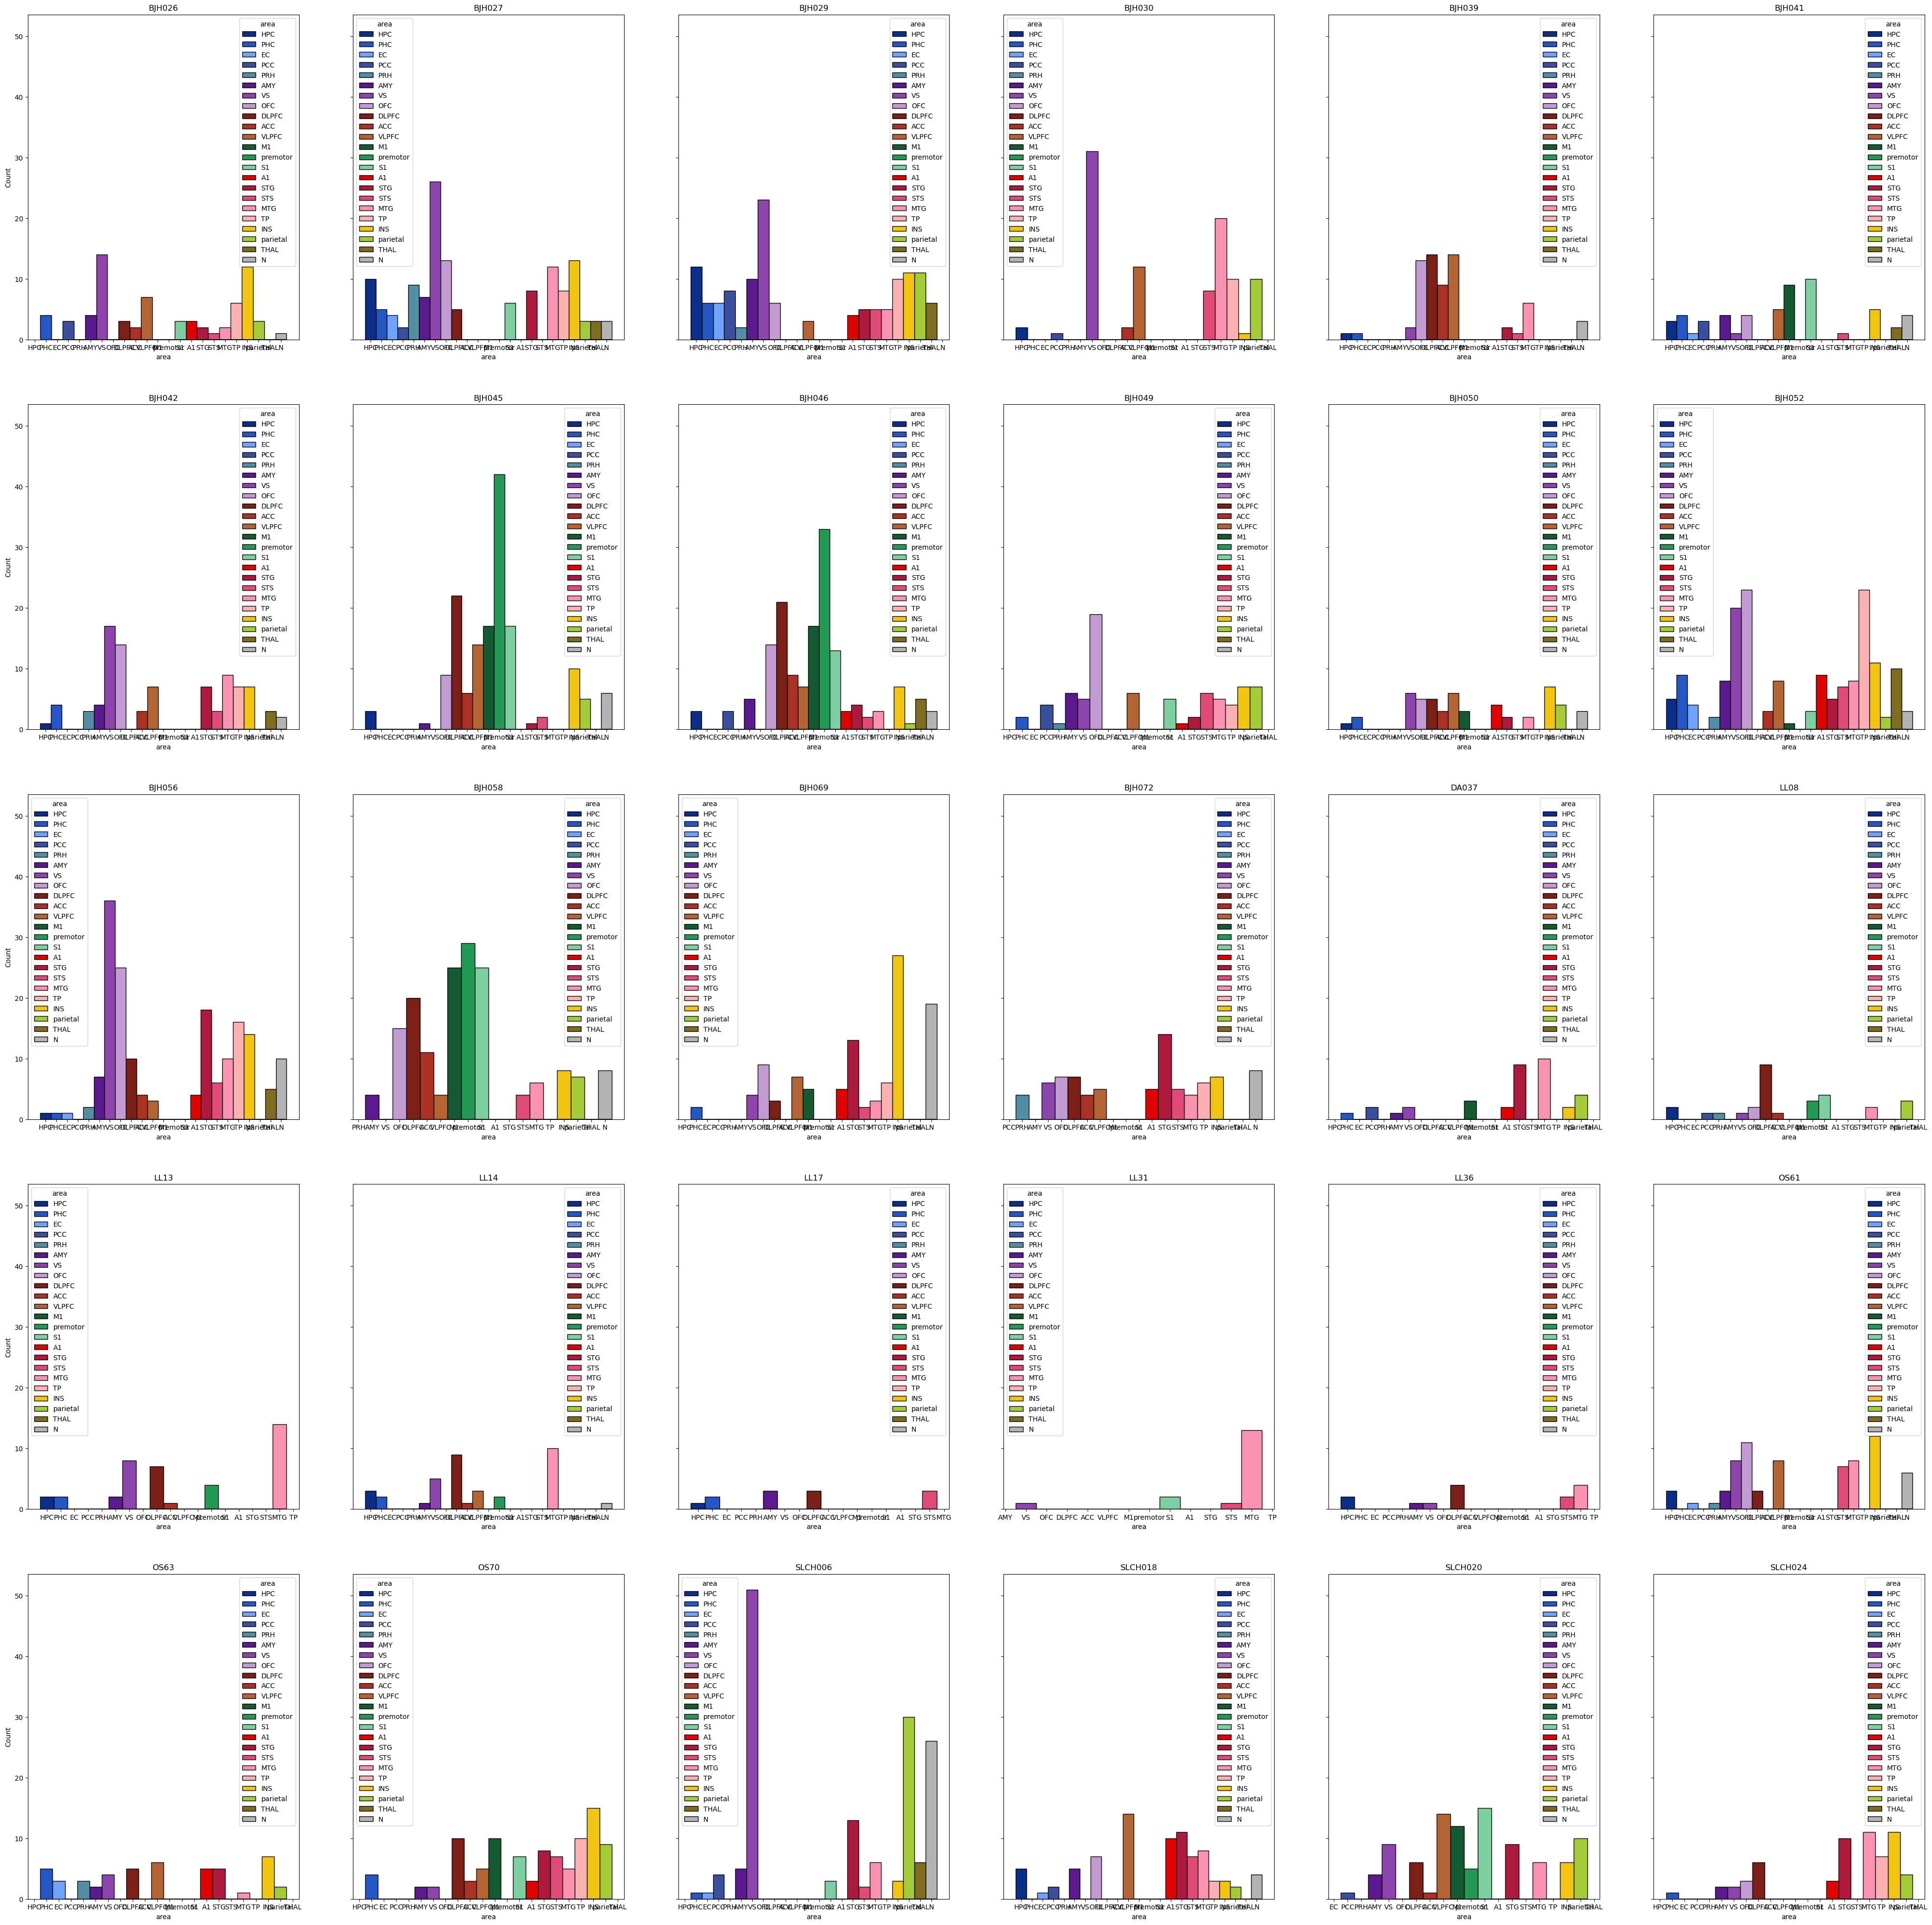

In [4]:
fig, ax = plt.subplots(5, 6, figsize=(50, 50), sharey=True) 
uniq_subj = np.unique(subj_list)
for sub, a in zip(uniq_subj, ax.flatten()) : 
    df_sub=df[df['subject'] == sub]

    df_sub["area"] = pd.Categorical(
        df_sub["area"],
        categories=COL_REG.keys(),
        ordered=True
    )

    df_ordered = df.sort_values("area")

    sns.histplot(df_sub, x = 'area',hue='area', palette=COL_REG, ax=a, alpha = 1)

    a.set_title(sub)

## Look at a specific Area

<Axes: xlabel='Count', ylabel='subject'>

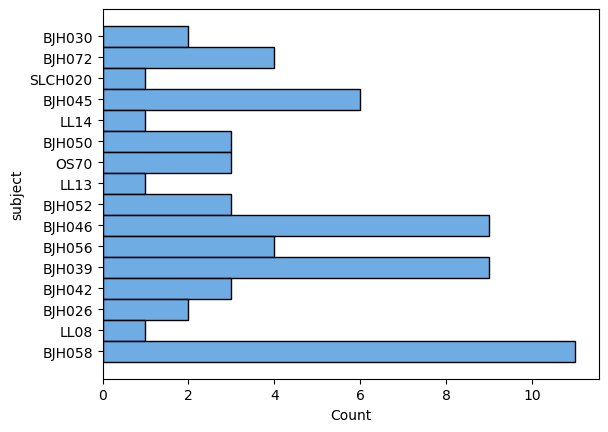

In [28]:
sns.histplot(df[df['area']=='ACC'], y='subject')

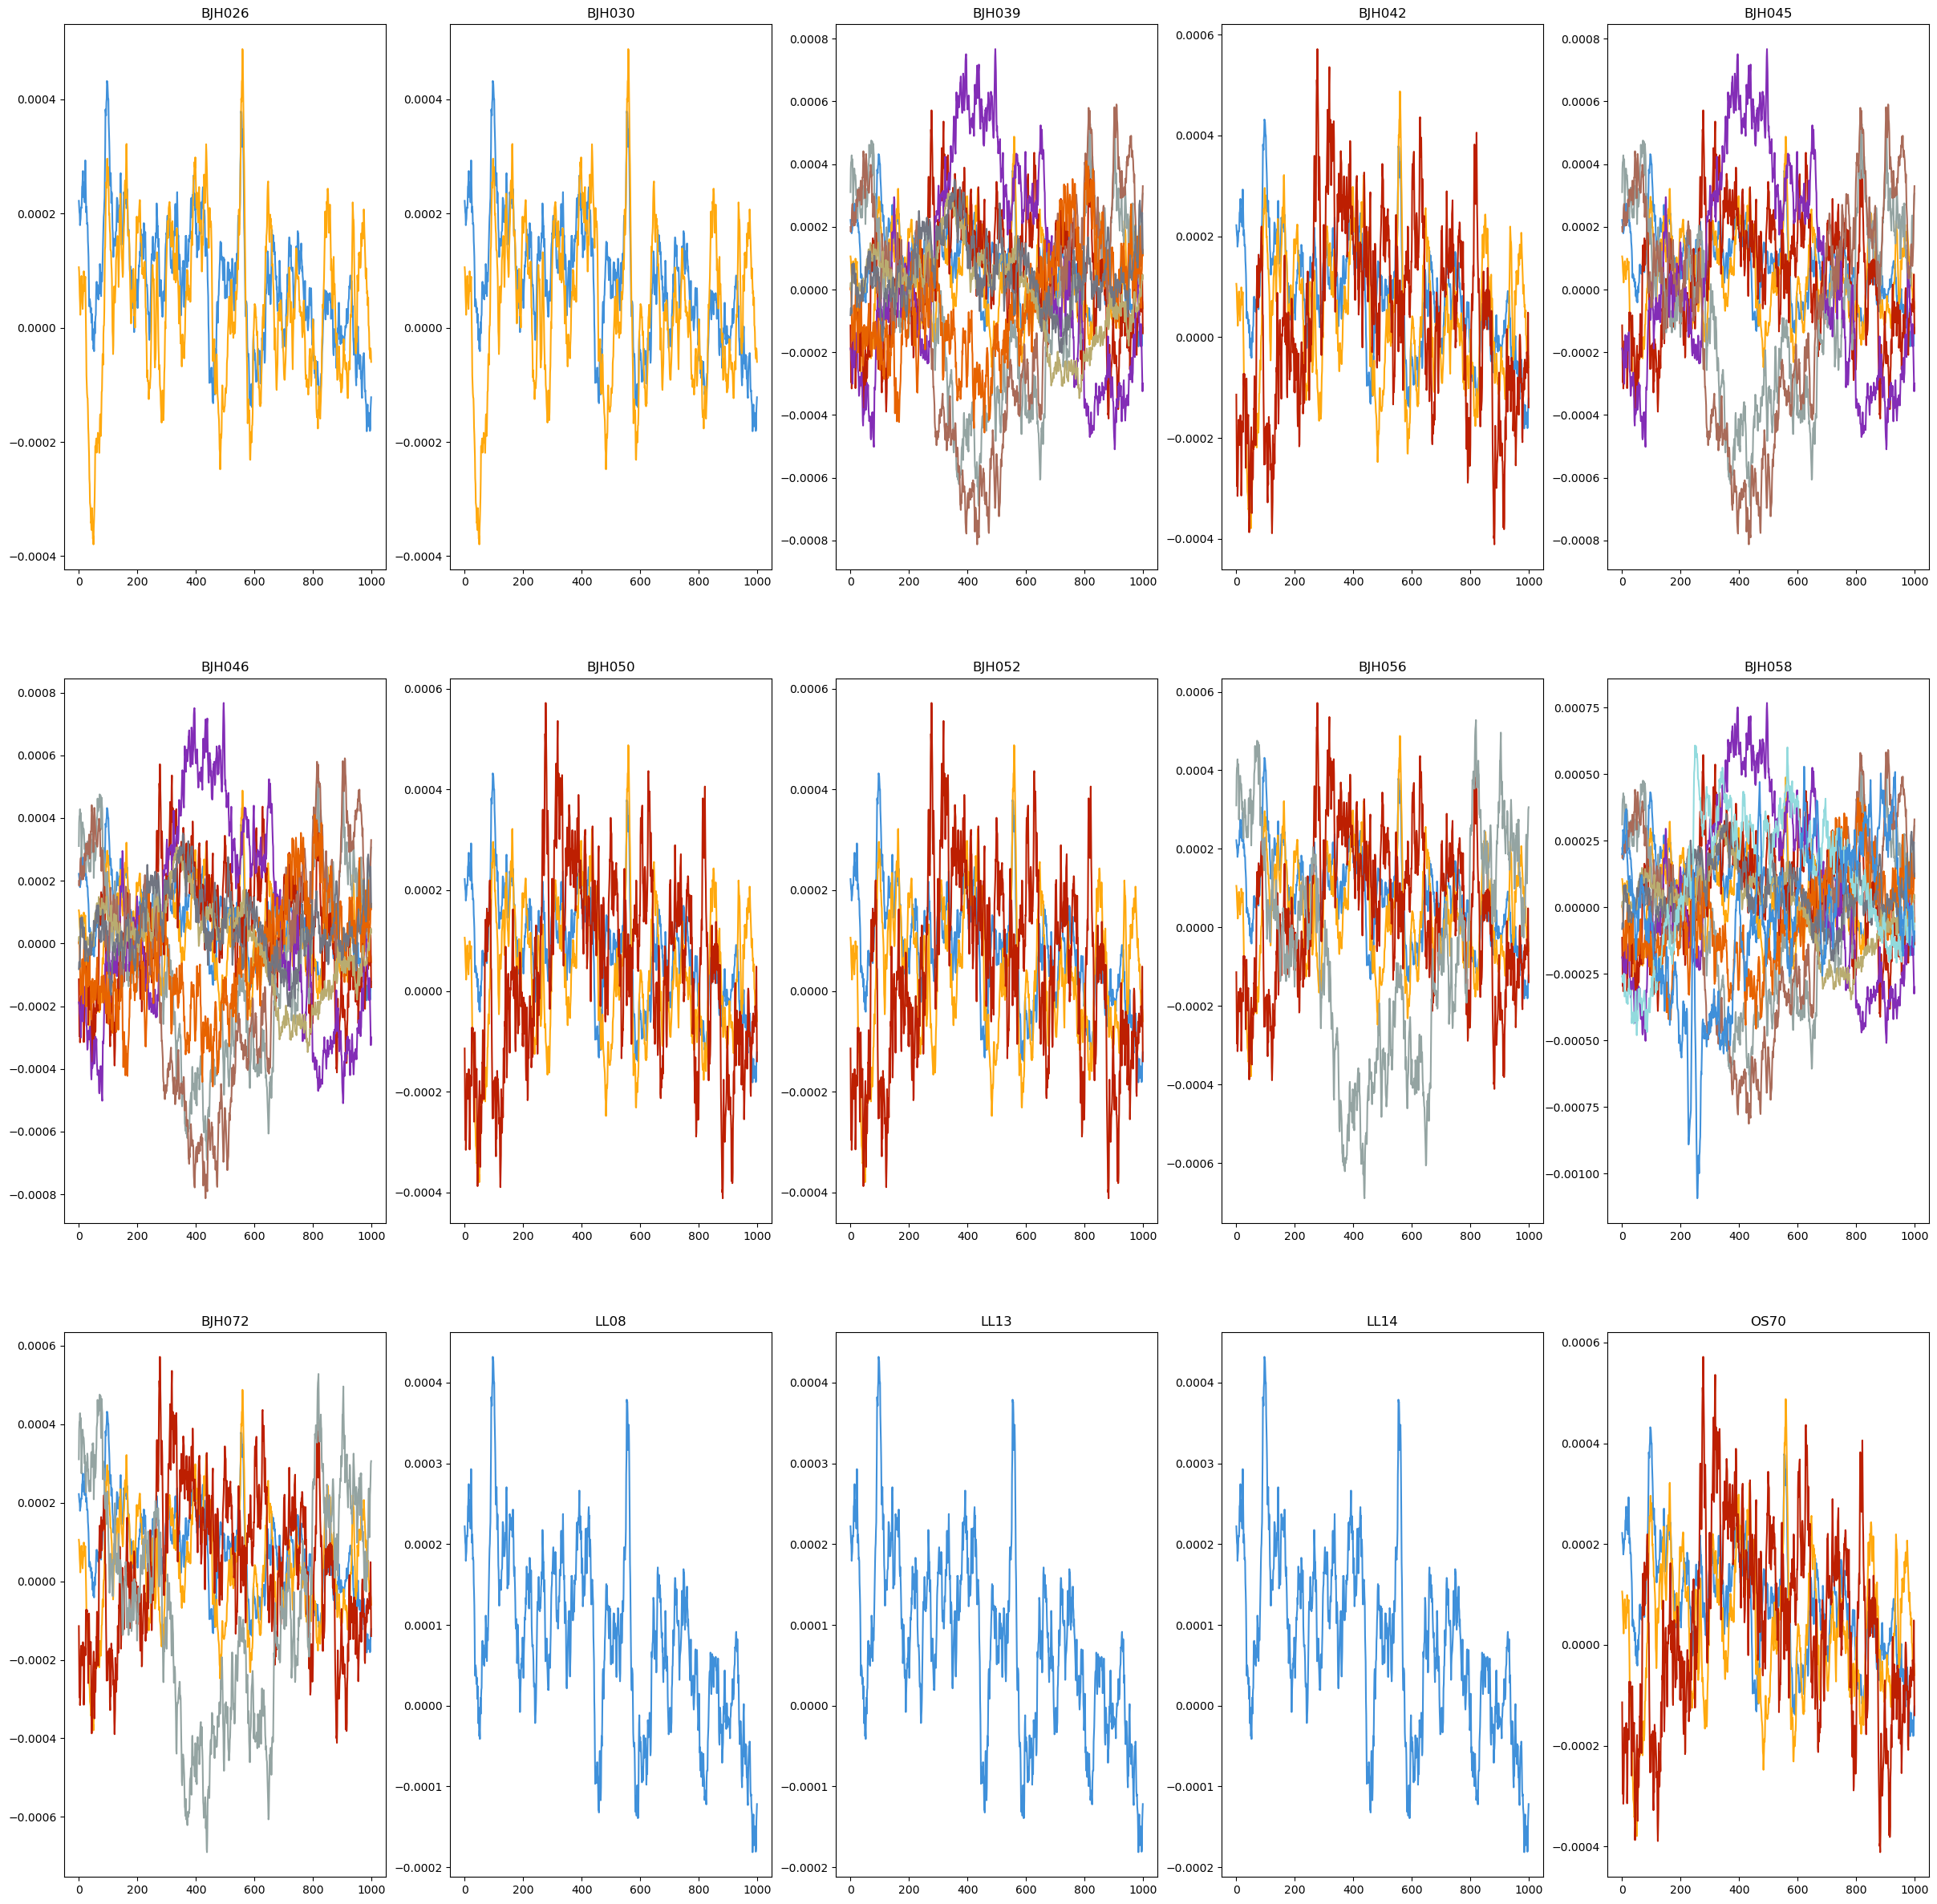

In [30]:
data = get_data_grp(subj_included=subj_included, type_data='epoch', data_path=epoch_path)
df_acc = df[df['area']=='ACC']
idx_acc =df_acc.index
data_acc = data[:, idx_acc, :]
fig, ax = plt.subplots(3, int(len(np.unique(df_acc.subject.values))/3), figsize=(30, 30))

for a, subj in zip(ax.flatten(), np.unique(df_acc.subject.values)) :
    ids_subj = df_acc[df_acc['subject']==subj].reset_index().index
    #a.plot(data_acc[0, ids_subj, :].T, ls=':') #, c='b')
    #a.plot(data_acc[1, ids_subj, :].T, ls='--') #c='r')
    a.plot(data_acc[:, ids_subj, :].mean(0).T)
    a.set_title(subj)

## compare with grp PCA

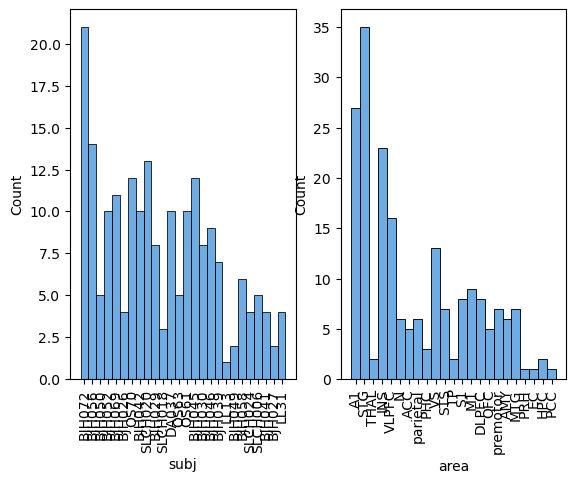

In [31]:
# extract the eletrod that impact the first compo 
compo_grp = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_bb_mean/grp_Compo_PCA5.csv')
grp_df = pd.DataFrame(compo_grp).drop(columns = ['Unnamed: 0', 'freq', 'compo'])
grp_df = pd.DataFrame(CompoThr(grp_df.values)).T
grp_df['subj']=subj_list
grp_df['area']=region

compo_l = grp_df.nlargest(200, 0)
fig, ax =plt.subplots(1, 2)
sns.histplot(data=compo_l, x='subj', ax=ax[0])
ax[0].tick_params(axis='x', labelrotation=90)

sns.histplot(data=compo_l, x='area', ax=ax[1])
ax[1].tick_params(axis='x', labelrotation=90)

## Get single subject PCA

In [32]:
# get the single subject PCA
subj_xtrans1=pd.read_csv(OUT_PATH + f'/subjPCA/Broadband/subj_Xtrans_PCAcompo0_mean.csv').drop(columns =['Unnamed: 0'])
subj_xtrans2=pd.read_csv(OUT_PATH + f'/subjPCA/Broadband/subj_Xtrans_PCAcompo1_mean.csv').drop(columns =['Unnamed: 0'])
subj_xtrans3=pd.read_csv(OUT_PATH + f'/subjPCA/Broadband/subj_Xtrans_PCAcompo2_mean.csv').drop(columns =['Unnamed: 0'])

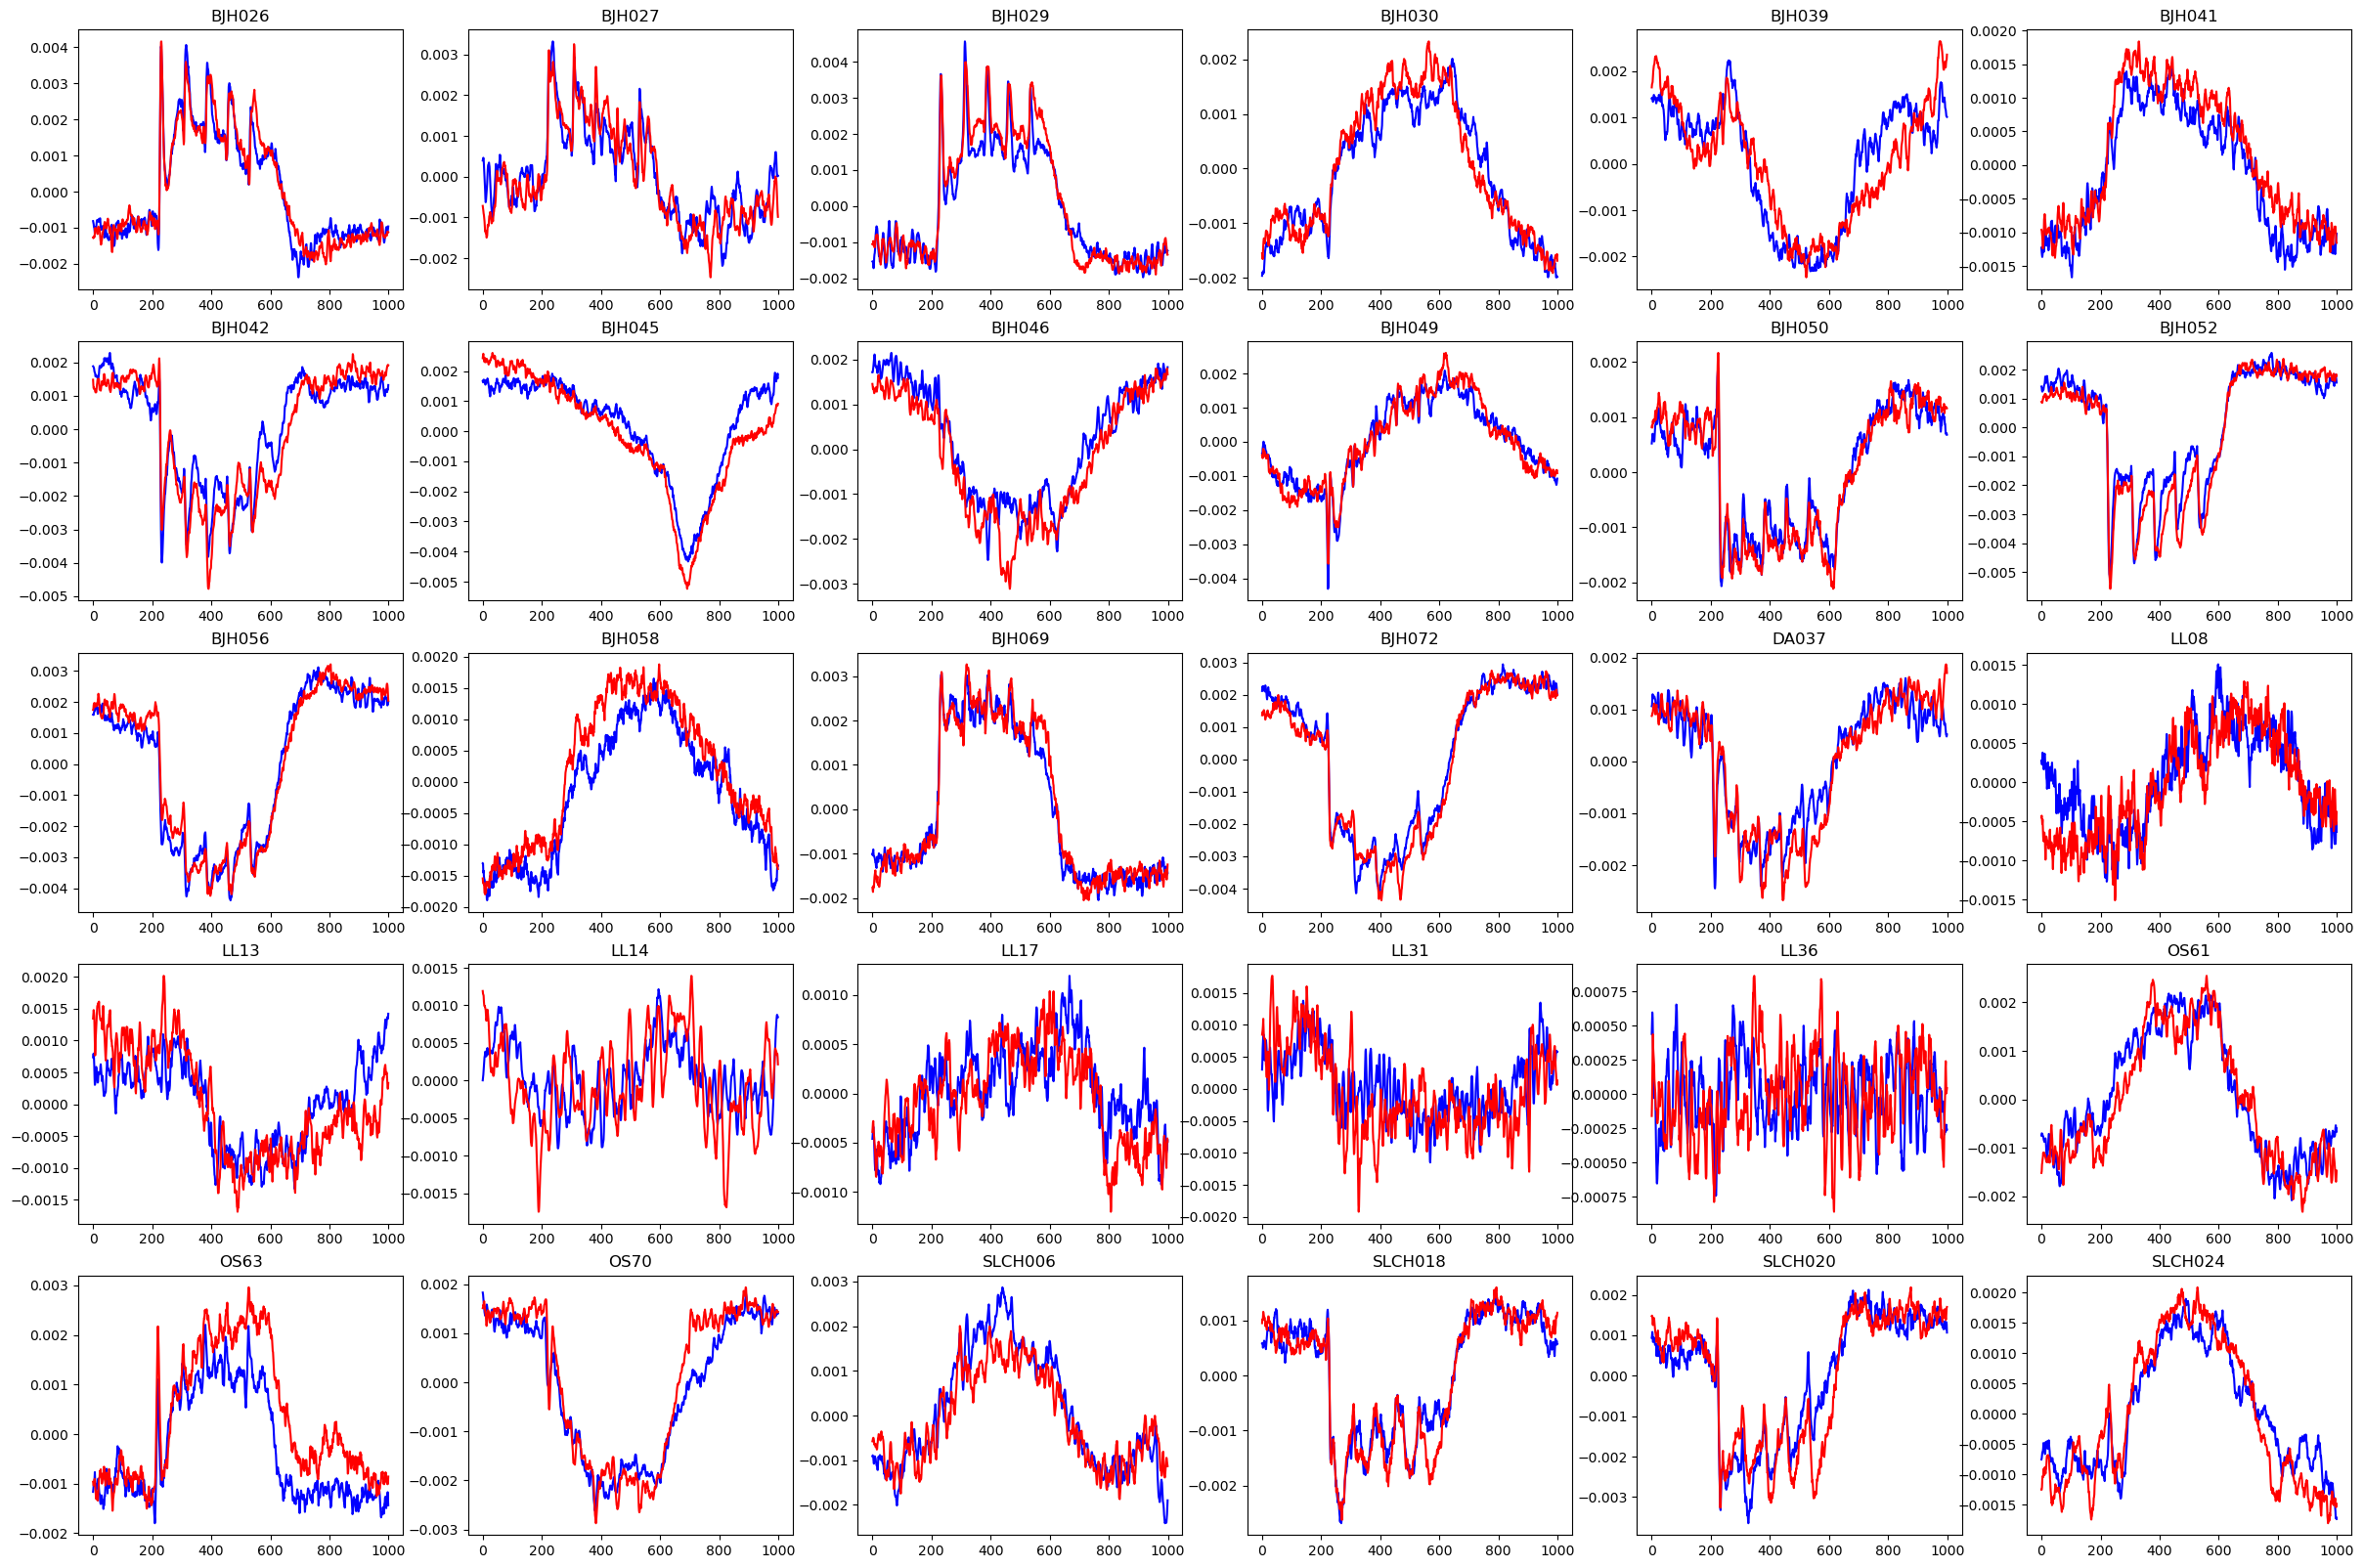

In [33]:
fig, ax = plt.subplots(5, 6, figsize=(30, 20))
data=subj_xtrans1
list_subj = np.unique(data.subj.values)
for i, a in enumerate(ax.flatten()) : 
    subj = list_subj[i]
    condi0_subj  = data[data['subj'] == subj].loc[:, :'999'].values
    a.plot(condi0_subj[0, :], c='b')
    a.plot(condi0_subj[1, :], c='r')

    a.set_title(subj)

## Compare the coverage with MEG

Can we weight the contribution of MEG source according to iEEG ? 

In [16]:
# Compare with MEG?
# Get MEG grp level 
import mat73
import scipy
MEG_data_compo = pd.read_csv('MEG/MEG_componants.csv')
MEG_data_timecourseM = pd.read_csv('MEG/MEG_timecourseM1.csv')
MEG_data_timecourseN = pd.read_csv('MEG/MEG_timecourseN.csv')


file_path = 'MEG/Data_Example.mat'
MEGdata = mat73.loadmat(file_path)
MEGdata = MEGdata['data'][:, :, :2]

file_path = 'MEG/MNI152_8mm_coord_dyi.mat'
MEG_coords = scipy.io.loadmat(file_path)['MNI8']

In [85]:
from scipy.spatial import cKDTree

tree = cKDTree(np.array(coord))
dist, idx = tree.query(MEG_coords)
radius = 5 # to optimize with the number of mixing source to make something possible 
mask = dist <= radius
meg_coords_masked = MEG_coords[mask]

radius= 3 # to optimize with the number of mixing source to make something possible 
neighbors = tree.query_ball_point(meg_coords_masked, radius)
counts = np.array([len(x) for x in neighbors])
meg_repeated = np.repeat(meg_coords_masked, counts, axis=0)

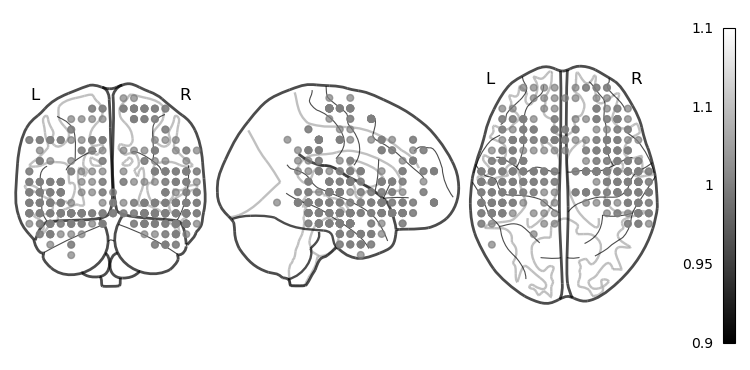

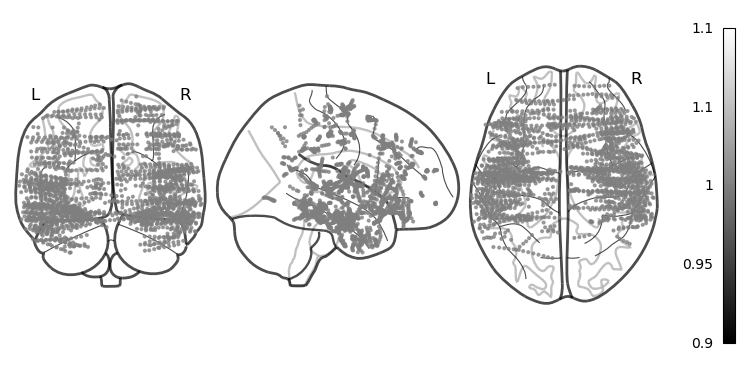

In [86]:
from nilearn import plotting
plotting.plot_markers([1]*meg_repeated.shape[0], meg_repeated) 
plotting.plot_markers([1]*len(coord), np.array(coord))


In [87]:
meg_signal_masked = MEGdata[mask, :, :]
meg_repeated = np.repeat(meg_signal_masked, counts, axis=0)

pca = PCA(2)
meg_mask_trans = pca.fit_transform(meg_signal_masked.mean(2).T)
mag_mask_rep = pca.fit_transform(meg_repeated.mean(2).T)
meg_trans = pca.fit_transform(MEGdata.mean(2).T)

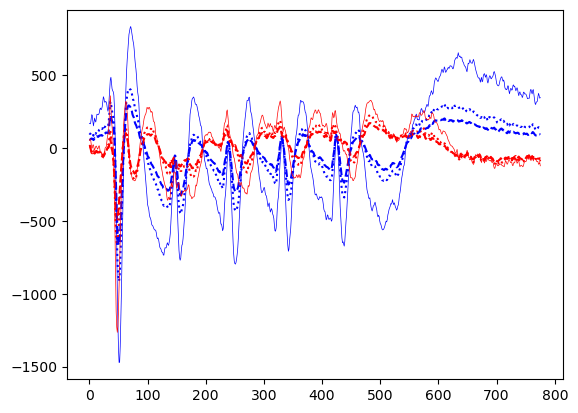

In [88]:
plt.plot(meg_mask_trans[:, 0], c='b', ls=':' )
plt.plot(meg_mask_trans[:, 1], c='r', ls=':' )

plt.plot(mag_mask_rep[:, 0], c='b', ls='--')
plt.plot(mag_mask_rep[:, 1], c='r', ls='--')

plt.plot(meg_trans[:, 0],c='b', linewidth = 0.5)
plt.plot(meg_trans[:, 1], c='r', linewidth = 0.5)